In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
from ecm_simplification_functions.parser import full_simplify
import matplotlib.pyplot as plt

%matplotlib inline

data_dir = Path("data_test_1")

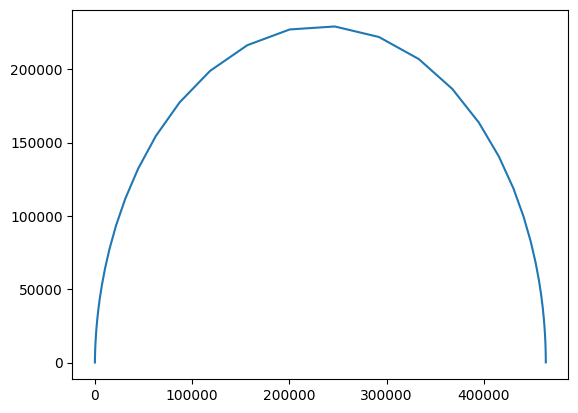

{'schema_version': 1,
 'sample_index': 4,
 'initial_circuit': 'R1-[P2,R3]-[P4,R5]-[P6,R7]',
 'initial_parameters': {'R1': 0.01,
  'P2w': 1.463709532723171e-08,
  'P2n': 0.988403723481057,
  'R3': 463651.23257025034,
  'P4w': 0.0008967684728469168,
  'P4n': 0.7532757832368064,
  'R5': 2.4480015211418262,
  'P6w': 0.000671631124296109,
  'P6n': 0.7547863844031069,
  'R7': 7738.097176917573},
 'final_circuit': 'R1-[P2,R3]-[P4,R5]',
 'final_parameters': {'P2w': np.float64(1.4427713052811333e-08),
  'P2n': 1.0,
  'R3': np.float64(451638.81314548844),
  'P4w': np.float64(3.58943089067152e-07),
  'P4n': np.float64(0.8997930047096079),
  'R5': np.float64(12046.932903543246),
  'R1': 0.01},
 'intermediate': {'simplified_circuit': 'R1-[C2,R3]-[P4,R5]',
  'simplified_parameters': {'R1': np.float64(5.817923640374975e-260),
   'C2': np.float64(1.4427713052811333e-08),
   'R3': np.float64(451638.81314548844),
   'P4w': np.float64(3.58943089067152e-07),
   'P4n': np.float64(0.8997930047096079),
   'R

In [26]:
circuit = "R1-[P2,R3]-[P4,R5]"
idx = 4

sample_file = data_dir / circuit / f"sample_{idx:04d}.csv"
info_file = data_dir / circuit / f"sample_{idx:04d}.pkl"

sample = pd.read_csv(sample_file)
info = pd.read_pickle(info_file)

freq1 = sample.freq.values
Zre = sample.Z_real.values
Zim = sample.Z_imag.values
Z1 = Zre + 1j * Zim
p0 = info["initial_parameters"]

plt.figure()
plt.plot(Zre, -Zim)
plt.show()

info

In [23]:
np.random.seed(1717)
results = full_simplify(
    "R1-[P2,R3]-[P4,R5]-[P6,R7]",
    freq1,
    Z1,
    p0,
    identifiability_thresh=1e-6,
    verbose=True,
    fit_kwargs={
        "max_iters": 10,
        "min_iters": 2,
        "max_nfev": 100,
    },
)
results

Iteration 1:
Current circuit: R1-[P2,R3]-[P4,R5]-[P6,R7]
Current parameters: {'R1': 0.01, 'P2w': 1.463709532723171e-08, 'P2n': 0.988403723481057, 'R3': 463651.23257025034, 'P4w': 0.0008967684728469168, 'P4n': 0.7532757832368064, 'R5': 2.4480015211418262, 'P6w': 0.000671631124296109, 'P6n': 0.7547863844031069, 'R7': 7738.097176917573}
Simplified circuit after combining series and parallel components: R1-[C2,R3]-[P4,R5]-[P6,R7]
Corresponding parameters:
{'R1': 0.01,
 'C2': 1.463709532723171e-08,
 'R3': 463651.23257025034,
 'P4w': 0.0008967684728469168,
 'P4n': 0.7532757832368064,
 'R5': 2.4480015211418262,
 'P6w': 0.000671631124296109,
 'P6n': 0.7547863844031069,
 'R7': 7738.097176917573}
Dropping unidentifiable components...
Circuit: R1-[C2,R3]-[P4,R5]-[P6,R7]
Original parameters:
{'R1': 0.01,
 'C2': 1.463709532723171e-08,
 'R3': 463651.23257025034,
 'P4w': 0.0008967684728469168,
 'P4n': 0.7532757832368064,
 'R5': 2.4480015211418262,
 'P6w': 0.000671631124296109,
 'P6n': 0.7547863844031

('R1-[C2,R3]',
 {'R1': np.float64(6.576784453431946),
  'C2': np.float64(1.3228420238778418e-08),
  'R3': np.float64(464469.8493652265)},
 {0: {'input_circuit': 'R1-[P2,R3]-[P4,R5]-[P6,R7]',
   'input_params': {'R1': 0.01,
    'P2w': 1.463709532723171e-08,
    'P2n': 0.988403723481057,
    'R3': 463651.23257025034,
    'P4w': 0.0008967684728469168,
    'P4n': 0.7532757832368064,
    'R5': 2.4480015211418262,
    'P6w': 0.000671631124296109,
    'P6n': 0.7547863844031069,
    'R7': 7738.097176917573},
   'series_parallel_combined': ('R1-[C2,R3]-[P4,R5]-[P6,R7]',
    {'R1': 0.01,
     'C2': 1.463709532723171e-08,
     'R3': 463651.23257025034,
     'P4w': 0.0008967684728469168,
     'P4n': 0.7532757832368064,
     'R5': 2.4480015211418262,
     'P6w': 0.000671631124296109,
     'P6n': 0.7547863844031069,
     'R7': 7738.097176917573}),
   'fim_identifiability': [('R1-[C2,R3]-[P6,R7]',
     {'R1': np.float64(0.598331169633166),
      'C2': np.float64(1.5188670261861672e-07),
      'R3': n

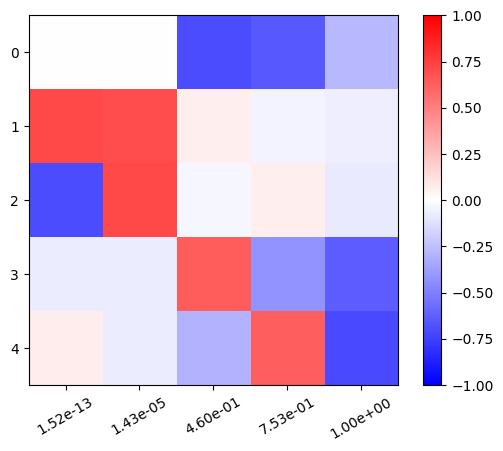

In [24]:
eigvecs = results[-1][1]["fim_identifiability"][0][-1]
eigvals = results[-1][1]["fim_identifiability"][0][-2]

plt.figure()
plt.imshow(eigvecs, vmin=-1, vmax=1, cmap="bwr")
plt.colorbar()
plt.xticks(range(len(eigvals)), [f"{val:0.2e}" for val in eigvals], rotation=30)
plt.show()